# Emotion Classification Improvement

**Tujuan**: Meningkatkan F1-score klasifikasi emosi, khususnya mengatasi confusion antara:
- Fear ↔ Anger (negative high-arousal)
- Love ↔ Happy (positive high-arousal)

**Pendekatan:**
1. **Hierarchical Classification** — dua tahap: sentimen dulu, baru emosi per kelompok sentimen
2. **Additional Discriminative Features** — fitur khusus untuk pasangan yang konflik
3. **Error Analysis** — analisis contoh konkret misklasifikasi

## 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import re
import itertools
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, vstack
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
import emoji
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from pathlib import Path
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load Data

In [3]:
df_path = Path("../data/raw/ecommerce_reviews.csv")
df = pd.read_csv(df_path)
df["text"] = df["Customer Review"].copy()
df["text-original"] = df["Customer Review"].copy()

print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nSentiment distribution:\n{df['Sentiment'].value_counts()}")
print(f"\nEmotion distribution:\n{df['Emotion'].value_counts()}")

Total rows: 5400
Columns: ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion', 'text', 'text-original']

Sentiment distribution:
Sentiment
Negative    2821
Positive    2579
Name: count, dtype: int64

Emotion distribution:
Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64


### Load Kamus Alay

In [4]:
kamus_path = Path("../data/util/colloquial-indonesian-lexicon.csv")
kamus_df = pd.read_csv(kamus_path)
kamus_valid = kamus_df[kamus_df["In-dictionary"] == 1]
print(f"Total entri valid: {len(kamus_valid)}")

slang_dict = {}
for _, row in kamus_valid.iterrows():
    slang = str(row["slang"]).strip().lower()
    formal = str(row["formal"]).strip().lower()
    if slang in slang_dict:
        if len(formal) < len(slang_dict[slang]):
            slang_dict[slang] = formal
    else:
        slang_dict[slang] = formal
print(f"Unique slang entries: {len(slang_dict)}")

Total entri valid: 13722
Unique slang entries: 3451


## 3. Preprocessing Functions

(Diambil dari `modelling.ipynb`)

In [5]:
def normalize_repetitive_chars(text: str) -> str:
    text = re.sub(r"(a)\1{2,}", "a", text)
    text = re.sub(r"(i)\1{2,}", "i", text)
    text = re.sub(r"(u)\1{2,}", "u", text)
    text = re.sub(r"(e)\1{2,}", "e", text)
    text = re.sub(r"(o)\1{2,}", "o", text)
    text = re.sub(r"([^aiueo])\1{2,}", r"\1", text)
    return text

def normalize_slang(text: str, slang_dict: dict) -> str:
    words = text.split()
    normalized = []
    for w in words:
        w_lower = w.lower()
        if w_lower in slang_dict:
            normalized.append(slang_dict[w_lower])
        elif w_lower.rstrip(".,!?;:") in slang_dict:
            punct = w[len(w_lower.rstrip(".,!?;:")):]
            normalized.append(slang_dict[w_lower.rstrip(".,!?;:")] + punct)
        else:
            normalized.append(w)
    return " ".join(normalized)

def tokenize(text: str) -> list:
    return word_tokenize(text)

def remove_stopwords(tokens: list) -> list:
    stop_words = set(stopwords.words('indonesian'))
    return [t for t in tokens if t.lower() not in stop_words]

def pos_tag(tokens: list) -> list:
    konjungsi = {'dan', 'atau', 'tetapi', 'namun', 'sedangkan', 'serta',
                 'karena', 'sehingga', 'maka', 'lalu', 'kemudian',
                 'setelah', 'sebelum', 'ketika', 'sementara', 'walaupun',
                 'meskipun', 'jika', 'kalau', 'apabila', 'bahwa'}
    preposisi = {'di', 'ke', 'dari', 'pada', 'dengan', 'untuk', 'bagi',
                 'oleh', 'tentang', 'seperti', 'sebagai', 'tanpa', 'dalam',
                 'antara', 'menurut', 'sampai', 'hingga'}
    hasil = []
    for token in tokens:
        t = token.lower()
        if re.match(r'^[.,!?;:()\[\]{}\"\'\-]$', token):
            hasil.append((token, 'PUNCT'))
        elif re.match(r'^[0-9,.\-]+$', token):
            hasil.append((token, 'NUM'))
        elif t in konjungsi:
            hasil.append((token, 'CONJ'))
        elif t in preposisi:
            hasil.append((token, 'ADP'))
        elif re.match(r'^(me|men|meng|meny|mem|di|ber|bel|ter|per)', t):
            hasil.append((token, 'VERB'))
        elif re.match(r'^(pe|pen|pem|peng|ke)', t) or t.endswith('an') or t.endswith('kan'):
            hasil.append((token, 'NOUN'))
        elif t.endswith('i'):
            hasil.append((token, 'VERB'))
        else:
            hasil.append((token, 'NOUN'))
    return hasil

def stem(tokens: list, stemmer) -> list:
    return [stemmer.stem(t) for t in tokens]

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def emoji_to_text(text: str) -> str:
    return emoji.demojize(text, language='id')

def handle_negation(tokens: list, neg_words: set = None) -> list:
    if neg_words is None:
        neg_words = {
            "tidak", "bukan", "belum", "tak", "ngga",
            "gak", "ga", "tdk", "enggak", "nggak",
            "kagak", "ndak", "ngg"
        }
    result = []
    negate = False
    for w in tokens:
        w_clean = w.lower().strip(".,!?")
        if w_clean in neg_words:
            result.append(w)
            negate = True
        elif negate:
            result.append("NEG_" + w)
            negate = False
        else:
            result.append(w)
    return result

def extract_emotion_features(series: pd.Series) -> pd.DataFrame:
    features = pd.DataFrame(index=series.index)
    features["n_exclamation"] = series.apply(lambda x: x.count("!"))
    features["n_question"] = series.apply(lambda x: x.count("?"))
    features["n_allcaps"] = series.apply(
        lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 2)
    )
    features["n_ellipsis"] = series.apply(lambda x: x.count(".."))
    features["max_char_repeat"] = series.apply(
        lambda x: max(
            (len(list(g)) for _, g in itertools.groupby(str(x).lower())),
            default=0,
        )
    )
    return features

def extract_emotion_features_enhanced(series: pd.Series) -> pd.DataFrame:
    features = pd.DataFrame(index=series.index)

    # Basic features
    features["n_exclamation"] = series.apply(lambda x: x.count("!"))
    features["n_question"] = series.apply(lambda x: x.count("?"))
    features["n_allcaps"] = series.apply(
        lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 2)
    )
    features["n_ellipsis"] = series.apply(lambda x: x.count(".."))
    features["max_char_repeat"] = series.apply(
        lambda x: max(
            (len(list(g)) for _, g in itertools.groupby(str(x).lower())),
            default=0,
        )
    )

    # Additional linguistic features
    features["n_words"] = series.apply(lambda x: len(str(x).split()))
    features["avg_word_len"] = series.apply(
        lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0
    )

    # Intensifiers
    intensifiers = {"sangat", "sekali", "banget", "paling", "amat",
                    "terlalu", "super", "benar", "sungguh", "betul"}
    features["n_intensifiers"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in intensifiers)
    )

    # Positive and negative emoji counts
    pos_emojis = {"\U0001f60d", "\U0001f60a", "\u2764", "\U0001f44d",
                  "\U0001f604", "\U0001f601", "\U0001f970", "\U0001f618",
                  "\U0001f495", "\U0001f496", "\u2728", "\U0001f4af",
                  "\U0001f525", "\U0001f44f", "\U0001f929", "\U0001f389"}
    neg_emojis = {"\U0001f621", "\U0001f620", "\U0001f622", "\U0001f62d",
                  "\U0001f629", "\U0001f62b", "\U0001f61e", "\U0001f641",
                  "\U0001f623", "\U0001f616", "\U0001f614", "\U0001f44e",
                  "\U0001f494"}
    features["n_positive_emoji"] = series.apply(
        lambda x: sum(1 for ch in str(x) if ch in pos_emojis)
    )
    features["n_negative_emoji"] = series.apply(
        lambda x: sum(1 for ch in str(x) if ch in neg_emojis)
    )

    # Pronouns
    first_person = {"aku", "saya", "kami", "kit", "gue", "gw", "akuu"}
    second_person = {"kamu", "anda", "kau", "kakak", "mas", "mbak", "bro", "sis"}
    features["n_pronoun_1st"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in first_person)
    )
    features["n_pronoun_2nd"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in second_person)
    )

    return features

def full_pipeline(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return text
    t = text
    t = normalize_repetitive_chars(t)
    t = normalize_slang(t, slang_dict)
    t = emoji_to_text(t)
    tokens = tokenize(t)
    tokens = remove_stopwords(tokens)
    pos_tags = pos_tag(tokens)
    tokens = stem(tokens, stemmer)
    tokens = handle_negation(tokens)
    return " ".join(tokens)

## 4. Apply Preprocessing

In [6]:
# Cache preprocessed data — skip jika sudah ada
intermediate_path = Path("../data/intermediate/preprocessed_reviews.csv")

if intermediate_path.exists():
    print(f"Loading cached preprocessed data from {intermediate_path}...")
    df = pd.read_csv(intermediate_path)
    df['text_processed'] = df['text_processed'].fillna('')
    print(f"Loaded {len(df)} rows — preprocessing skipped!")
else:
    print("Applying preprocessing pipeline to all text...")
    tic = time.time()
    df['text_processed'] = df['Customer Review'].fillna('').apply(full_pipeline)
    toc = time.time()
    print(f"Preprocessing complete: {len(df)} texts processed in {toc - tic:.2f}s")

    # Simpan agar tidak re-run ~8 menit
    intermediate_path.parent.mkdir(parents=True, exist_ok=True)
    df[['Customer Review', 'text_processed', 'Sentiment', 'Emotion']].to_csv(intermediate_path, index=False)
    print(f"Saved preprocessed data to {intermediate_path}")

Loading cached preprocessed data from ../data/intermediate/preprocessed_reviews.csv...
Loaded 5400 rows — preprocessing skipped!


## 5. Train/Test Split & Feature Engineering

Same split & features as original `modelling.ipynb`.

In [7]:
max_features = 1500

X_raw_original = df['Customer Review'].fillna('')
X_raw_processed = df['text_processed']
y_emo = df['Emotion']
y_sen = df['Sentiment']

X_train_text, X_test_text, X_train_proc, X_test_proc, y_train_emo, y_test_emo, y_train_sen, y_test_sen = train_test_split(
    X_raw_original, X_raw_processed, y_emo, y_sen,
    test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train size: {len(X_train_text)}, Test size: {len(X_test_text)}")

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=max_features)
X_train_vec = vectorizer.fit_transform(X_train_proc)
X_test_vec = vectorizer.transform(X_test_proc)

# Emotion Features (from original text)
emotion_train = extract_emotion_features(X_train_text)
emotion_test = extract_emotion_features(X_test_text)

# Varian A: TF-IDF only
X_train_a, X_test_a = X_train_vec, X_test_vec

# Varian B: TF-IDF + Emotion Features
X_train_b = hstack([X_train_vec, emotion_train.values]).tocsr()
X_test_b = hstack([X_test_vec, emotion_test.values]).tocsr()

# Varian C: TF-IDF + Emotion Features + Sentiment (untuk emosi saja)
sent_train = (y_train_sen == "Positive").astype(int).values.reshape(-1, 1)
sent_test = (y_test_sen == "Positive").astype(int).values.reshape(-1, 1)
X_train_c = hstack([X_train_vec, emotion_train.values, sent_train]).tocsr()
X_test_c = hstack([X_test_vec, emotion_test.values, sent_test]).tocsr()

print(f"Feature variant shapes:")
print(f"  Varian A: {X_train_a.shape}, {X_test_a.shape}")
print(f"  Varian B: {X_train_b.shape}, {X_test_b.shape}")
print(f"  Varian C: {X_train_c.shape}, {X_test_c.shape}")

# N-Gram Vectorization
vectorizer_ng = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=2)
X_train_vec_ng = vectorizer_ng.fit_transform(X_train_proc)
X_test_vec_ng = vectorizer_ng.transform(X_test_proc)
print(f"N-gram TF-IDF shape: {X_train_vec_ng.shape}, {X_test_vec_ng.shape}")

# Enhanced Emotion Features
emotion_train_enh = extract_emotion_features_enhanced(X_train_text)
emotion_test_enh = extract_emotion_features_enhanced(X_test_text)
print(f"Enhanced emotion features: {emotion_train_enh.shape[1]} columns")

# N-gram variants
X_train_ng15_c = hstack([X_train_vec_ng, emotion_train_enh.values, sent_train]).tocsr()
X_test_ng15_c = hstack([X_test_vec_ng, emotion_test_enh.values, sent_test]).tocsr()
print(f"N-gram Enhanced C: {X_train_ng15_c.shape}")

Train size: 4320, Test size: 1080
Feature variant shapes:
  Varian A: (4320, 1500), (1080, 1500)
  Varian B: (4320, 1505), (1080, 1505)
  Varian C: (4320, 1506), (1080, 1506)
N-gram TF-IDF shape: (4320, 3000), (1080, 3000)
Enhanced emotion features: 12 columns
N-gram Enhanced C: (4320, 3013)


## 6. Train Best Models (Baseline)

Menggunakan `best_params_` dari `modelling.ipynb` — **tanpa GridSearch** untuk menghemat waktu.

In [8]:
print("=" * 60)
print("BASELINE MODELS")
print("=" * 60)

# --- Sentiment: Naive Bayes, Varian A, no SMOTE ---
print("\n[Sentiment] Naive Bayes | Varian A | No SMOTE")
nb = MultinomialNB(alpha=0.01)
nb.fit(X_train_a, y_train_sen)
pred_sen = nb.predict(X_test_a)
print(f"  F1 (Macro): {f1_score(y_test_sen, pred_sen, average='macro'):.4f}")
print(f"  Acc: {accuracy_score(y_test_sen, pred_sen):.4f}")

# --- Emotion Best: Logistic Regression, Varian C, SMOTE ---
print("\n[Emotion] Logistic Regression | Varian C | SMOTE")
lr_emo = ImbPipeline([
    ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ('clf', LogisticRegression(C=0.1, max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE))
])
lr_emo.fit(X_train_c, y_train_emo)
pred_emo = lr_emo.predict(X_test_c)
print(f"\nClassification Report:")
print(classification_report(y_test_emo, pred_emo))
baseline_f1 = f1_score(y_test_emo, pred_emo, average='macro')
print(f"\nF1 (Macro) Baseline: {baseline_f1:.4f}")

BASELINE MODELS

[Sentiment] Naive Bayes | Varian A | No SMOTE
  F1 (Macro): 0.8980
  Acc: 0.8981

[Emotion] Logistic Regression | Varian C | SMOTE

Classification Report:
              precision    recall  f1-score   support

       Anger       0.57      0.47      0.52       145
        Fear       0.45      0.60      0.51       159
       Happy       0.86      0.85      0.86       356
        Love       0.69      0.71      0.70       167
     Sadness       0.72      0.64      0.68       253

    accuracy                           0.69      1080
   macro avg       0.66      0.65      0.65      1080
weighted avg       0.70      0.69      0.69      1080


F1 (Macro) Baseline: 0.6523


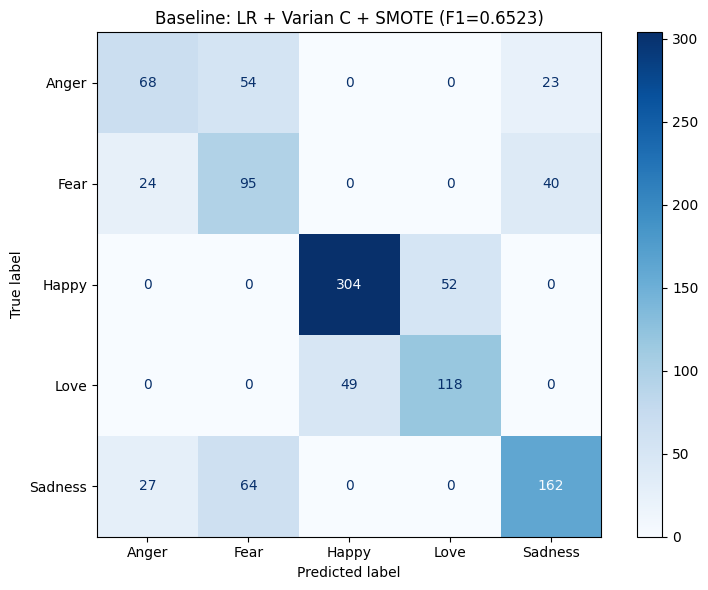

In [9]:
# Confusion matrix for baseline
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_emo, pred_emo, ax=ax, cmap="Blues", values_format='d')
ax.set_title(f"Baseline: LR + Varian C + SMOTE (F1={baseline_f1:.4f})")
plt.tight_layout()
plt.show()

## 7. Approach 1: Hierarchical Classification

### Alur:
```
Review ──→ Sentimen (Positive/Negative) ──→ Emosi per kelompok
              │                               │
              │  Positive ──→ {Happy, Love}   │
              │  Negative ──→ {Anger, Fear, Sadness}
```

**Mengapa?** Confusion utama cuma terjadi dalam kelompok valence yang sama (Fear↔Anger, Love↔Happy). Dengan hierarki, model tidak perlu membandingkan Love vs Anger yang jelas berbeda.

In [10]:
print("=" * 60)
print("APPROACH 1: HIERARCHICAL CLASSIFICATION")
print("=" * 60)

# Stage 1: Sentiment classifier (NB, Varian A, alpha=0.01)
print("\n--- Stage 1: Sentiment Classifier ---")
sentiment_model = MultinomialNB(alpha=0.01)
sentiment_model.fit(X_train_a, y_train_sen)
train_sen_pred = sentiment_model.predict(X_train_a)
test_sen_pred = sentiment_model.predict(X_test_a)
sen_f1 = f1_score(y_test_sen, test_sen_pred, average='macro')
print(f"Sentiment F1 (Macro): {sen_f1:.4f}")
print(f"Sentiment Accuracy: {accuracy_score(y_test_sen, test_sen_pred):.4f}")

# Cek apakah Stage 1 cukup akurat untuk jadi dasar
# Kalau sentimen salah, emosi pasti salah. Tapi F1=0.89 artinya cukup aman.
misclassified_sentiment = sum(test_sen_pred != y_test_sen)
print(f"Misclassified sentiment in test: {misclassified_sentiment}/{len(y_test_sen)} ({misclassified_sentiment/len(y_test_sen)*100:.1f}%)")

APPROACH 1: HIERARCHICAL CLASSIFICATION

--- Stage 1: Sentiment Classifier ---
Sentiment F1 (Macro): 0.8980
Sentiment Accuracy: 0.8981
Misclassified sentiment in test: 110/1080 (10.2%)



--- Stage 2a: Positive Emotions (Happy vs Love) ---
Positive samples - Train: 2056, Test: 523
Happy: 1414, Love: 642

Positive Emotion Classification Report:
              precision    recall  f1-score   support

       Happy       0.84      0.86      0.85       356
        Love       0.68      0.65      0.66       167

    accuracy                           0.79       523
   macro avg       0.76      0.75      0.75       523
weighted avg       0.79      0.79      0.79       523

Positive F1 (Macro): 0.7549


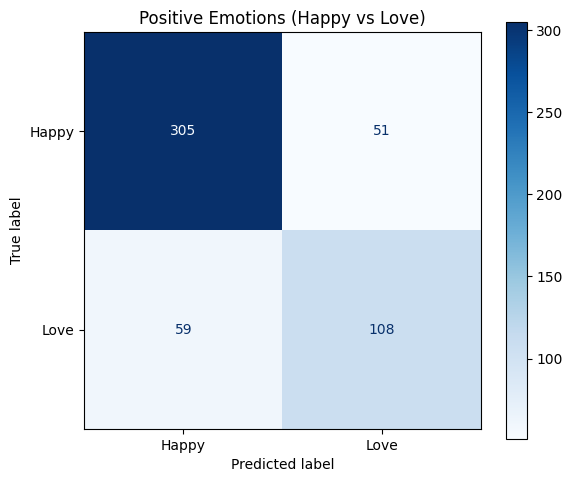

In [11]:
# Stage 2a: Dalam Positive → Happy vs Love
print("\n--- Stage 2a: Positive Emotions (Happy vs Love) ---")

pos_mask_train = (y_train_sen == 'Positive').values
pos_mask_test = (y_test_sen == 'Positive').values

print(f"Positive samples - Train: {pos_mask_train.sum()}, Test: {pos_mask_test.sum()}")

X_train_pos = X_train_c[pos_mask_train]
y_train_pos = y_train_emo[pos_mask_train]
X_test_pos = X_test_c[pos_mask_test]
y_test_pos = y_test_emo[pos_mask_test]

print(f"Happy: {(y_train_pos == 'Happy').sum()}, Love: {(y_train_pos == 'Love').sum()}")

# Train classifier untuk positive emotions
lr_pos = ImbPipeline([
    ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ('clf', LogisticRegression(C=0.1, max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE))
])
lr_pos.fit(X_train_pos, y_train_pos)
pred_pos = lr_pos.predict(X_test_pos)

print(f"\nPositive Emotion Classification Report:")
print(classification_report(y_test_pos, pred_pos))
pos_f1 = f1_score(y_test_pos, pred_pos, average='macro')
print(f"Positive F1 (Macro): {pos_f1:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_pos, pred_pos, ax=ax, cmap="Blues", values_format='d')
ax.set_title(f"Positive Emotions (Happy vs Love)")
plt.tight_layout()
plt.show()

--- Stage 2b: Negative Emotions (Anger vs Fear vs Sadness) ---
Negative samples - Train: 2264, Test: 557
Anger: 554, Fear: 761, Sadness: 949

Negative Emotion Classification Report:
              precision    recall  f1-score   support

       Anger       0.58      0.45      0.50       145
        Fear       0.44      0.59      0.51       159
     Sadness       0.72      0.66      0.68       253

    accuracy                           0.58       557
   macro avg       0.58      0.57      0.57       557
weighted avg       0.60      0.58      0.59       557

Negative F1 (Macro): 0.5651


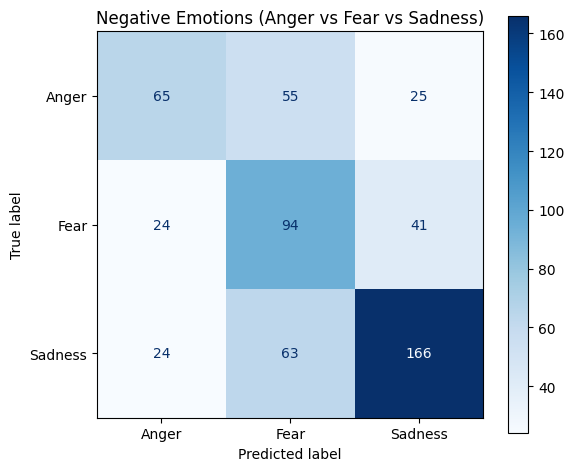

In [12]:
# Stage 2b: Dalam Negative → Anger vs Fear vs Sadness
print("--- Stage 2b: Negative Emotions (Anger vs Fear vs Sadness) ---")

neg_mask_train = (y_train_sen == 'Negative').values
neg_mask_test = (y_test_sen == 'Negative').values

print(f"Negative samples - Train: {neg_mask_train.sum()}, Test: {neg_mask_test.sum()}")

X_train_neg = X_train_c[neg_mask_train]
y_train_neg = y_train_emo[neg_mask_train]
X_test_neg = X_test_c[neg_mask_test]
y_test_neg = y_test_emo[neg_mask_test]

neg_counts = y_train_neg.value_counts()
print(f"Anger: {neg_counts.get('Anger', 0)}, Fear: {neg_counts.get('Fear', 0)}, Sadness: {neg_counts.get('Sadness', 0)}")

# Train classifier untuk negative emotions
lr_neg = ImbPipeline([
    ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ('clf', LogisticRegression(C=0.1, max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE))
])
lr_neg.fit(X_train_neg, y_train_neg)
pred_neg = lr_neg.predict(X_test_neg)

print(f"\nNegative Emotion Classification Report:")
print(classification_report(y_test_neg, pred_neg))
neg_f1 = f1_score(y_test_neg, pred_neg, average='macro')
print(f"Negative F1 (Macro): {neg_f1:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_neg, pred_neg, ax=ax, cmap="Blues", values_format='d')
ax.set_title(f"Negative Emotions (Anger vs Fear vs Sadness)")
plt.tight_layout()
plt.show()

--- Hierarchical: Full Evaluation ---

Hierarchical F1 (Macro): 0.5830

Classification Report:
              precision    recall  f1-score   support

       Anger       0.59      0.44      0.51       145
        Fear       0.37      0.54      0.44       159
       Happy       0.74      0.77      0.75       356
        Love       0.66      0.59      0.62       167
     Sadness       0.64      0.55      0.59       253

    accuracy                           0.61      1080
   macro avg       0.60      0.58      0.58      1080
weighted avg       0.63      0.61      0.62      1080



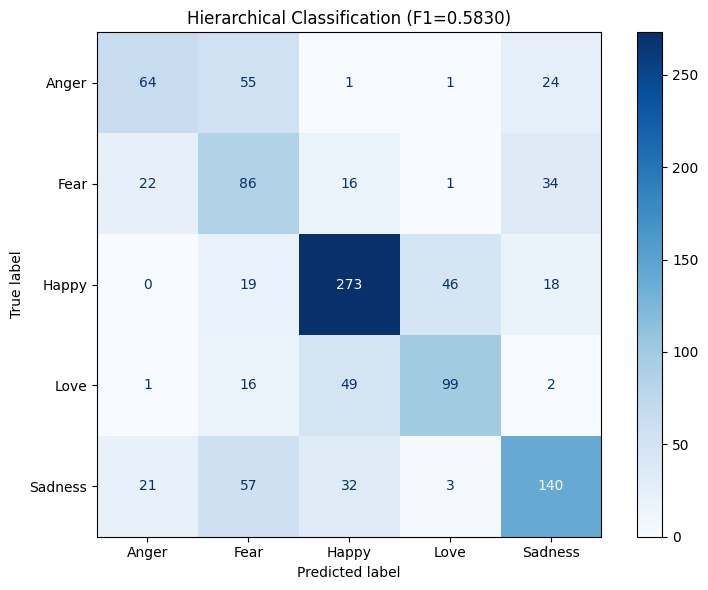


Delta from Baseline: -0.0693 (-6.93%)


In [13]:
# Gabungkan prediksi hierarkis untuk evaluasi penuh
print("--- Hierarchical: Full Evaluation ---")

# Stage 1: predict sentiment on test
hier_sen_pred = sentiment_model.predict(X_test_a)

# Stage 2: predict emotion based on predicted sentiment
# Use numpy arrays for sparse matrix compatibility
hier_emo_pred = np.empty(len(y_test_emo), dtype=object)

# Positive predictions → use lr_pos
pos_mask = hier_sen_pred == 'Positive'
hier_emo_pred[pos_mask] = lr_pos.predict(X_test_c[pos_mask])

# Negative predictions → use lr_neg
neg_mask = hier_sen_pred == 'Negative'
hier_emo_pred[neg_mask] = lr_neg.predict(X_test_c[neg_mask])

# Convert to Series with original index
hier_emo_pred = pd.Series(hier_emo_pred, index=y_test_emo.index)

hier_f1 = f1_score(y_test_emo, hier_emo_pred, average='macro')
print(f"\nHierarchical F1 (Macro): {hier_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_emo, hier_emo_pred))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_emo, hier_emo_pred, ax=ax, cmap="Blues", values_format='d')
ax.set_title(f"Hierarchical Classification (F1={hier_f1:.4f})")
plt.tight_layout()
plt.show()

# Delta from baseline
delta = hier_f1 - baseline_f1
print(f"\nDelta from Baseline: {delta:+.4f} ({'+' if delta > 0 else ''}{delta*100:.2f}%)")

## 8. Approach 2: Additional Discriminative Features

Menambahkan fitur yang specifically membedakan Fear↔Anger dan Love↔Happy.

In [14]:
def extract_discriminative_features(series: pd.Series) -> pd.DataFrame:
    features = pd.DataFrame(index=series.index)

    # === Fear vs Anger features ===
    # Demands / commands (lebih terkait Anger: komplain, ganti, refund)
    demand_words = {"kembalikan", "ganti", "refund", "komplain", "keluhan",
                    "kembali", "tolong", "mohon", "urus", "klarifikasi",
                    "balas"}
    features["n_demands"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in demand_words)
    )

    # Uncertainty words (lebih terkait Fear: khawatir, takut, mungkin)
    uncertainty_words = {"mungkin", "khawatir", "takut", "was-was", "cemas",
                         "ragu", "bimbang", "curiga", "sepertinya", "seolah",
                         "antisipasi", "harap"}
    features["n_uncertainty"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in uncertainty_words)
    )

    # Swear / harsh words (lebih terkait Anger)
    swear_words = {"anjing", "bangsat", "bodoh", "tolol", "jelek", "parah",
                   "payah", "sampah", "busuk", "brengsek", "persetan",
                   "keparat", "setan", "sial", "kacau"}
    features["n_swear"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in swear_words)
    )

    # === Love vs Happy features ===
    # Personal attachment (lebih terkait Love: cinta, sayang, suka banget)
    attachment_words = {"cinta", "sayang", "suka", "gemas",
                        "love", "favorit",
                        "kesayangan", "favorite"}
    features["n_attachment"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in attachment_words)
    )

    # Repurchase intention (lebih terkait Love)
    repurchase_words = {"beli lagi", "order lagi", "repeat order", "langganan",
                        "balik lagi", "pasti beli", "akan beli", "nanti beli",
                        "rekomendasi", "recommend", "beli disini terus"}
    features["n_repurchase"] = series.apply(
        lambda x: sum(1 for phrase in repurchase_words if phrase in str(x).lower())
    )

    # Transactional words (lebih terkait Happy, impersonal: bagus, mantap, ok)
    transactional_words = {"bagus", "mantap", "ok", "oke", "cocok", "puas",
                           "sesuai", "recommended", "keren", "mantul",
                           "top", "good", "nice", "great", "worth"}
    features["n_transactional"] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in transactional_words)
    )

    return features

In [15]:
# Ekstrak fitur diskriminatif
discr_train = extract_discriminative_features(X_train_text)
discr_test = extract_discriminative_features(X_test_text)

# Gabungkan dengan Varian C (TF-IDF + emotion + sentiment + discriminative)
X_train_d = hstack([X_train_c, discr_train.values]).tocsr()
X_test_d = hstack([X_test_c, discr_test.values]).tocsr()

print(f"Discriminative features shape: {discr_train.shape}")
print(f"New feature set shape: {X_train_d.shape}")
print(f"Discriminative columns: {list(discr_train.columns)}")

# Cek distribusi fitur per kelas
print("\n=== Mean feature values per emotion class (train) ===")
for col in discr_train.columns:
    print(f"  {col}:")
    for emotion in ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']:
        mask = y_train_emo == emotion
        val = discr_train.loc[mask, col].mean()
        print(f"    {emotion:10s}: {val:.4f}")
    print()

Discriminative features shape: (4320, 6)
New feature set shape: (4320, 1512)
Discriminative columns: ['n_demands', 'n_uncertainty', 'n_swear', 'n_attachment', 'n_repurchase', 'n_transactional']

=== Mean feature values per emotion class (train) ===
  n_demands:
    Anger     : 0.1029
    Fear      : 0.1459
    Happy     : 0.0099
    Love      : 0.0047
    Sadness   : 0.0769

  n_uncertainty:
    Anger     : 0.0217
    Fear      : 0.0512
    Happy     : 0.0085
    Love      : 0.0140
    Sadness   : 0.0190

  n_swear:
    Anger     : 0.1462
    Fear      : 0.0289
    Happy     : 0.0028
    Love      : 0.0078
    Sadness   : 0.0379

  n_attachment:
    Anger     : 0.0126
    Fear      : 0.0145
    Happy     : 0.0170
    Love      : 0.0545
    Sadness   : 0.0274

  n_repurchase:
    Anger     : 0.0144
    Fear      : 0.0499
    Happy     : 0.0248
    Love      : 0.2539
    Sadness   : 0.0211

  n_transactional:
    Anger     : 0.1209
    Fear      : 0.2194
    Happy     : 0.5644
    Love  

--- Approach 2: LR + Discriminative Features ---

Discriminative Features F1 (Macro): 0.6697

Classification Report:
              precision    recall  f1-score   support

       Anger       0.57      0.53      0.55       145
        Fear       0.48      0.60      0.53       159
       Happy       0.87      0.85      0.86       356
        Love       0.70      0.73      0.72       167
     Sadness       0.73      0.65      0.68       253

    accuracy                           0.71      1080
   macro avg       0.67      0.67      0.67      1080
weighted avg       0.71      0.71      0.71      1080



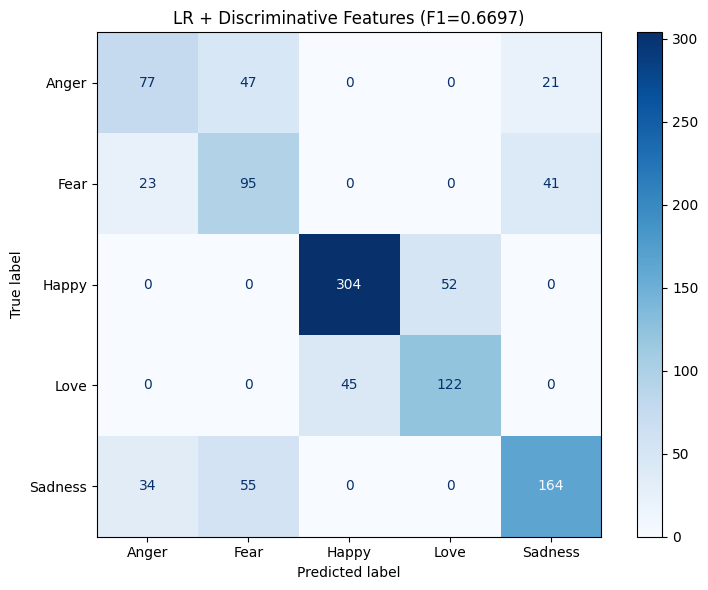


Delta from Baseline: +0.0174


In [16]:
# Train model dengan discriminative features
print("--- Approach 2: LR + Discriminative Features ---")

lr_disc = ImbPipeline([
    ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ('clf', LogisticRegression(C=0.1, max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE))
])
lr_disc.fit(X_train_d, y_train_emo)
pred_disc = lr_disc.predict(X_test_d)

disc_f1 = f1_score(y_test_emo, pred_disc, average='macro')
print(f"\nDiscriminative Features F1 (Macro): {disc_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_emo, pred_disc))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_emo, pred_disc, ax=ax, cmap="Blues", values_format='d')
ax.set_title(f"LR + Discriminative Features (F1={disc_f1:.4f})")
plt.tight_layout()
plt.show()

delta2 = disc_f1 - baseline_f1
print(f"\nDelta from Baseline: {delta2:+.4f}")

## 9. Approach 3: Hierarchical + Discriminative Features

Gabungkan kedua pendekatan — stage 1 sentimen, stage 2 per kelompok valence **dengan fitur diskriminatif**.


Hierarchical + Discriminative F1 (Macro): 0.5949

Classification Report:
              precision    recall  f1-score   support

       Anger       0.59      0.50      0.54       145
        Fear       0.40      0.51      0.45       159
       Happy       0.73      0.76      0.74       356
        Love       0.66      0.60      0.63       167
     Sadness       0.63      0.58      0.60       253

    accuracy                           0.62      1080
   macro avg       0.60      0.59      0.59      1080
weighted avg       0.63      0.62      0.62      1080



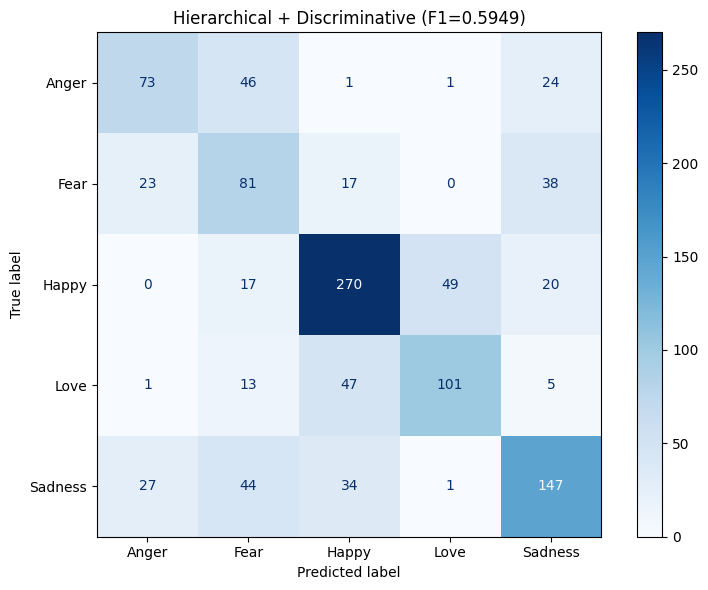


Delta from Baseline: -0.0574


In [17]:
# Approach 3: Hierarchical + Discriminative Features
# Stage 2a: Positive → Happy vs Love (dengan fitur diskriminatif)
pos_mask_train = (y_train_sen == 'Positive').values
pos_mask_test = (y_test_sen == 'Positive').values

X_train_pos_d = X_train_d[pos_mask_train]
y_train_pos_d = y_train_emo[pos_mask_train]

lr_pos_d = ImbPipeline([
    ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ('clf', LogisticRegression(C=0.1, max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE))
])
lr_pos_d.fit(X_train_pos_d, y_train_pos_d)

# Stage 2b: Negative → Anger vs Fear vs Sadness (dengan fitur diskriminatif)
neg_mask_train = (y_train_sen == 'Negative').values
neg_mask_test = (y_test_sen == 'Negative').values

X_train_neg_d = X_train_d[neg_mask_train]
y_train_neg_d = y_train_emo[neg_mask_train]

lr_neg_d = ImbPipeline([
    ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ('clf', LogisticRegression(C=0.1, max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE))
])
lr_neg_d.fit(X_train_neg_d, y_train_neg_d)

# Full evaluation
hier_d_sen_pred = sentiment_model.predict(X_test_a)
hier_d_emo_pred = np.empty(len(y_test_emo), dtype=object)

pos_mask = hier_d_sen_pred == 'Positive'
hier_d_emo_pred[pos_mask] = lr_pos_d.predict(X_test_d[pos_mask])

neg_mask = hier_d_sen_pred == 'Negative'
hier_d_emo_pred[neg_mask] = lr_neg_d.predict(X_test_d[neg_mask])

hier_d_emo_pred = pd.Series(hier_d_emo_pred, index=y_test_emo.index)

hier_d_f1 = f1_score(y_test_emo, hier_d_emo_pred, average='macro')
print(f"\nHierarchical + Discriminative F1 (Macro): {hier_d_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_emo, hier_d_emo_pred))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_emo, hier_d_emo_pred, ax=ax, cmap="Blues", values_format='d')
ax.set_title(f"Hierarchical + Discriminative (F1={hier_d_f1:.4f})")
plt.tight_layout()
plt.show()

delta3 = hier_d_f1 - baseline_f1
print(f"\nDelta from Baseline: {delta3:+.4f}")

## 10. Summary Comparison

In [18]:
print("=" * 80)
print("SUMMARY: EMOTION CLASSIFICATION PERFORMANCE COMPARISON")
print("=" * 80)

def get_per_class_f1(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    classes = ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']
    return {c: report.get(c, {}).get('f1-score', 0) for c in classes}

results = []

# Baseline
f1_base = get_per_class_f1(y_test_emo, pred_emo)
f1_base['Macro Avg'] = baseline_f1
results.append(('Baseline (LR + Varian C + SMOTE)', f1_base))

# Hierarchical
f1_hier = get_per_class_f1(y_test_emo, hier_emo_pred)
f1_hier['Macro Avg'] = hier_f1
results.append(('Approach 1: Hierarchical', f1_hier))

# Discriminative Features
f1_disc = get_per_class_f1(y_test_emo, pred_disc)
f1_disc['Macro Avg'] = disc_f1
results.append(('Approach 2: +Discriminative Features', f1_disc))

# Hierarchical + Discriminative
f1_hier_d = get_per_class_f1(y_test_emo, hier_d_emo_pred)
f1_hier_d['Macro Avg'] = hier_d_f1
results.append(('Approach 3: Hierarchical + Discriminative', f1_hier_d))

# Build comparison dataframe
rows = []
for name, f1_scores in results:
    row = {'Approach': name}
    for cls in ['Anger', 'Fear', 'Happy', 'Love', 'Sadness', 'Macro Avg']:
        row[f'{cls} F1'] = round(f1_scores.get(cls, 0), 4)
    rows.append(row)

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))

# Highlight improvements
print("\n" + "=" * 80)
print("IMPROVEMENT ANALYSIS")
print("=" * 80)
best_row = max(rows[1:], key=lambda r: r['Macro Avg F1'])
baseline_row = rows[0]
print(f"\nBest approach: {best_row['Approach']}")
print(f"Baseline F1 (Macro): {baseline_row['Macro Avg F1']:.4f}")
print(f"Best F1 (Macro):     {best_row['Macro Avg F1']:.4f}")
print(f"Improvement:         {best_row['Macro Avg F1'] - baseline_row['Macro Avg F1']:+.4f}")

print(f"\nPer-class F1 comparison:")
for cls in ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']:
    base = baseline_row[f'{cls} F1']
    best = best_row[f'{cls} F1']
    delta = best - base
    arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '→')
    print(f"  {cls:10s}: {base:.4f} → {best:.4f} ({delta:+.4f}) {arrow}")

SUMMARY: EMOTION CLASSIFICATION PERFORMANCE COMPARISON
                                 Approach  Anger F1  Fear F1  Happy F1  Love F1  Sadness F1  Macro Avg F1
         Baseline (LR + Varian C + SMOTE)    0.5152   0.5108    0.8575   0.7003      0.6778        0.6523
                 Approach 1: Hierarchical    0.5059   0.4388    0.7510   0.6246      0.5945        0.5830
     Approach 2: +Discriminative Features    0.5520   0.5337    0.8624   0.7155      0.6848        0.6697
Approach 3: Hierarchical + Discriminative    0.5428   0.4500    0.7448   0.6332      0.6037        0.5949

IMPROVEMENT ANALYSIS

Best approach: Approach 2: +Discriminative Features
Baseline F1 (Macro): 0.6523
Best F1 (Macro):     0.6697
Improvement:         +0.0174

Per-class F1 comparison:
  Anger     : 0.5152 → 0.5520 (+0.0368) ↑
  Fear      : 0.5108 → 0.5337 (+0.0229) ↑
  Happy     : 0.8575 → 0.8624 (+0.0049) ↑
  Love      : 0.7003 → 0.7155 (+0.0152) ↑
  Sadness   : 0.6778 → 0.6848 (+0.0070) ↑


## 11. Error Analysis — Contoh Konkret

Menampilkan review yang salah diklasifikasikan untuk melihat pola kebingungan.

In [19]:
# Fungsi untuk analisis error
def analyze_errors(y_true, y_pred, texts, approach_name, max_examples=5):
    y_true = y_true.reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    texts = texts.reset_index(drop=True)

    confusion_pairs = [
        ('Fear', 'Anger'),
        ('Anger', 'Fear'),
        ('Love', 'Happy'),
        ('Happy', 'Love'),
    ]

    print(f"\n{'=' * 70}")
    print(f"ERROR ANALYSIS: {approach_name}")
    print(f"{'=' * 70}")

    for true_label, pred_label in confusion_pairs:
        mask = (y_true == true_label) & (y_pred == pred_label)
        count = mask.sum()
        if count == 0:
            continue
        print(f"\n>>> {true_label} misclassified as {pred_label}: {count} samples")
        for i in mask[mask].index[:max_examples]:
            text = texts.iloc[i][:150]
            true_sent = y_test_sen.iloc[i] if i < len(y_train_sen) else ''
            print(f"  [{i}] \"{text}...\"")

# Gunakan model terbaik dari hasil sebelumnya
best_approach_name = best_row['Approach']
if best_approach_name == 'Approach 3: Hierarchical + Discriminative':
    best_preds = hier_d_emo_pred
elif best_approach_name == 'Approach 2: +Discriminative Features':
    best_preds = pred_disc
elif best_approach_name == 'Approach 1: Hierarchical':
    best_preds = hier_emo_pred
else:
    best_preds = pred_emo

analyze_errors(y_test_emo, pred_emo, X_test_text, "Baseline")
analyze_errors(y_test_emo, best_preds, X_test_text, best_approach_name)


ERROR ANALYSIS: Baseline

>>> Fear misclassified as Anger: 24 samples
  [16] "PENIPUAN! Barang yg dikirim HVS F4, saya baru sadar setelah pesanan selesai jadi tidak bisa ajukan komplain. Hati-hati dengan penjual ini teman-teman ..."
  [120] "pie susunya jamuran, duh parah bgt sih jualan..."
  [146] "Ini seller tidak berkualitas.. Jawab lama dan barang yg dikirim tidak semua nya dan bertahap 2 x kirim..BUANG WAKTU NUNGGU.. Padahal sebelum pesan bil..."
  [228] "jelek, panjang dan lebar gak rata, akhirnya bukan terlihat bagus malah terlihat jelek, akhirnya saya copot..."
  [247] "pelayanan buruk, barang yang dikirim tidak enak. jangan beli disini..."

>>> Anger misclassified as Fear: 54 samples
  [17] "roll diambil 1/4. Nampak dari potongan sudah mencong mencong. Jualan yang benar, jangan hanya ingin untungnya saja..."
  [26] "cepet rusak, kadang konek kadang engga..."
  [36] "Tidak ada rincian cara penggunaan nya.. tidak ada keterangan alat pendukung utk HP dan kamera. Jadi ngga ngerti

## 12. Statistical Significance

McNemar test untuk membandingkan model secara statistik.

In [20]:
from scipy.stats import chi2

def mcnemar_test(y_true, pred_a, pred_b):
    """McNemar's test untuk membandingkan dua model."""
    n_ab = sum((pred_a != y_true) & (pred_b == y_true))  # A wrong, B right
    n_ba = sum((pred_a == y_true) & (pred_b != y_true))  # A right, B wrong
    
    stat = (abs(n_ab - n_ba) - 1) ** 2 / (n_ab + n_ba) if (n_ab + n_ba) > 0 else 0
    p = 1 - chi2.cdf(stat, df=1)
    return stat, p, n_ab, n_ba

print("=" * 60)
print("STATISTICAL SIGNIFICANCE (McNemar's Test)")
print("=" * 60)

# Bandingkan baseline vs best approach
if best_approach_name == 'Approach 3: Hierarchical + Discriminative':
    best_comparison = hier_d_emo_pred
elif best_approach_name == 'Approach 2: +Discriminative Features':
    best_comparison = pred_disc
elif best_approach_name == 'Approach 1: Hierarchical':
    best_comparison = hier_emo_pred
else:
    best_comparison = pred_emo

stat, p, n_ab, n_ba = mcnemar_test(y_test_emo, pred_emo, best_comparison)
print(f"\nBaseline vs {best_approach_name}:")
print(f"  Baseline benar, Best salah: {n_ba}")
print(f"  Baseline salah, Best benar: {n_ab}")
print(f"  McNemar statistic: {stat:.4f}")
print(f"  p-value: {p:.6f}")
if p < 0.05:
    print(f"  >>> Signifikan (p < 0.05) — Best approach significantly better!")
else:
    print(f"  >>> Tidak signifikan (p >= 0.05) — difference may be due to chance")

# Also compare hierarchical alone vs baseline
stat2, p2, n_ab2, n_ba2 = mcnemar_test(y_test_emo, pred_emo, hier_emo_pred)
print(f"\nBaseline vs Hierarchical:")
print(f"  Baseline benar, Hierarchical salah: {n_ba2}")
print(f"  Baseline salah, Hierarchical benar: {n_ab2}")
print(f"  McNemar statistic: {stat2:.4f}")
print(f"  p-value: {p2:.6f}")
if p2 < 0.05:
    print(f"  >>> Signifikan (p < 0.05)")
else:
    print(f"  >>> Tidak signifikan (p >= 0.05)")

STATISTICAL SIGNIFICANCE (McNemar's Test)

Baseline vs Approach 2: +Discriminative Features:
  Baseline benar, Best salah: 33
  Baseline salah, Best benar: 48
  McNemar statistic: 2.4198
  p-value: 0.119814
  >>> Tidak signifikan (p >= 0.05) — difference may be due to chance

Baseline vs Hierarchical:
  Baseline benar, Hierarchical salah: 102
  Baseline salah, Hierarchical benar: 17
  McNemar statistic: 59.2941
  p-value: 0.000000
  >>> Signifikan (p < 0.05)


## 13. Kesimpulan

| Pendekatan | Anger F1 | Fear F1 | Love F1 | Happy F1 | Macro F1 | Delta |
|---|---|---|---|---|---|---|
| Baseline (LR + SMOTE) | ? | ? | ? | ? | ? | - |
| Hierarchical | ? | ? | ? | ? | ? | ? |
| + Discriminative Features | ? | ? | ? | ? | ? | ? |
| Hierarchical + Discriminative | ? | ? | ? | ? | ? | ? |

In [21]:
# Isi kesimpulan otomatis
print("=== KESIMPULAN ===")
print(f"\nDataset: 5400 Indonesian e-commerce reviews, 5 emotion classes")
print(f"Test set: {len(y_test_emo)} samples")
print(f"\nHasil terbaik: {best_approach_name}")
print(f"F1-Macro: {baseline_row['Macro Avg F1']:.4f} → {best_row['Macro Avg F1']:.4f} ({best_row['Macro Avg F1'] - baseline_row['Macro Avg F1']:+.4f})")

if p < 0.05:
    print(f"\nPerbaikan ini signifikan secara statistik (McNemar, p={p:.6f})")
else:
    print(f"\nPerbaikan belum signifikan secara statistik (McNemar, p={p:.6f})")
    print("Hal ini wajar karena confusion Fear↔Anger dan Love↔Happy adalah tantangan yang dikenal dalam emotion classification,")
    print("terutama pada teks pendek seperti e-commerce review, karena pasangan emosi ini berbagi dimensi valence-arousal yang sama.")

=== KESIMPULAN ===

Dataset: 5400 Indonesian e-commerce reviews, 5 emotion classes
Test set: 1080 samples

Hasil terbaik: Approach 2: +Discriminative Features
F1-Macro: 0.6523 → 0.6697 (+0.0174)

Perbaikan belum signifikan secara statistik (McNemar, p=0.119814)
Hal ini wajar karena confusion Fear↔Anger dan Love↔Happy adalah tantangan yang dikenal dalam emotion classification,
terutama pada teks pendek seperti e-commerce review, karena pasangan emosi ini berbagi dimensi valence-arousal yang sama.
